In [1]:
import pandas as pd

#-- load 
df_SL_rpk = pd.read_csv('../preprocessing/earliest_tp_rpk_avg_value_for_cohort_techreps_071626.csv').set_index('peptide')
df_hbdb_rpk = pd.read_csv('../preprocessing/hbdb_pass_100k_techreps_averaged_071626.csv').set_index('peptide')

df_sl_z = pd.read_csv('../z_score_df_SL_over_US_090226.csv').set_index('peptide')
df_hbdb_z = pd.read_csv('../z_hbdb_loo_results_090226.csv').set_index('peptide')

peps_metadata = (
pd.read_csv('../lassa_library_sequences_species_standardized_070726.csv').rename(columns={'seq_id': 'peptide'})
)
#-- correct wrong genus name
peps_metadata.loc[peps_metadata['genus'] == 'Arenavirus', 'genus'] = 'Mammarenavirus'

In [2]:
Z_THRESH = 3
SENS_MIN = 0.05
SPEC_MIN = 0.99

### calculate peptide sensitivity / specificity and select hits

In [3]:
#-- per peptide stats (sensitivity / specificity etc.)
def seropositivity_stats(df_sl_z, df_hbdb_z, metadata, z_thresh=Z_THRESH):
    pass_sl = df_sl_z > z_thresh
    pass_hbdb = df_hbdb_z > z_thresh

    stats = pd.concat(
        [pass_sl.mean(axis=1), pass_hbdb.mean(axis=1)], 
        axis=1, keys=['frac_pass_z_in_SL', 'frac_pass_z_in_US'] #performs multiindex on colums
    ).reset_index()

    stats = stats.merge(
        metadata[['peptide', 'sequence', 'species', 'genus', 'subfamily', 'family', 'order', 
                  'protein_name', 'accession', 'collection_date', 'collection_date_standardized', 'geo_loc_name', 'host']], 
                  on = 'peptide', how='left'
    )

    stats['delta'] = stats['frac_pass_z_in_SL'] - stats['frac_pass_z_in_US']
    stats['sensitivity'] = stats['frac_pass_z_in_SL']
    stats['specificity'] = 1 - stats['frac_pass_z_in_US']
    stats['youden'] = stats['sensitivity'] + stats['specificity'] - 1

    pass_bool = pd.concat([pass_sl, pass_hbdb], axis=1).reset_index()

    return stats, pass_bool

#-- get dataframes
df_fractions, df_pass_z_boolean = seropositivity_stats(df_sl_z, df_hbdb_z, peps_metadata)

hits = df_fractions[
    (df_fractions['sensitivity'] >= SENS_MIN) & 
    (df_fractions['specificity'] >= SPEC_MIN)
].copy()


### remove non-viral and plant viral families

In [4]:
#filtering out taxa I don't want to include downstream, such as Trypanosomatidae and Konkoviridae

TAXON_LEVEL = 'family'
TAXON_TO_REMOVE = ['Trypanosomatidae', 'Konkoviridae']

ACCESSION_TO_REMOVE = ['WAK75154.1', 'ANT96597.1'] #this is an ampicillin resistance protein from an artificial Zika 'vaccine' vector

hits = hits[~hits[TAXON_LEVEL].isin(TAXON_TO_REMOVE)].copy()

hits = hits[~hits['accession'].isin(ACCESSION_TO_REMOVE)]

In [5]:
hits['species'].nunique()
hits.shape

(1274, 19)

### add k-mer based clustering

In [6]:
import networkx as nx
from collections import defaultdict

K = 7

def get_kmers(sequence, k=K):
    sequence = str(sequence).upper()
    return {
        sequence[i:i+k]
        for i in range(len(sequence) - k + 1)
    }

kmer_to_peptides = defaultdict(list)

for peptide, sequence in hits[['peptide', 'sequence']].itertuples(index=False):
    for kmer in get_kmers(sequence):
        kmer_to_peptides[kmer].append(peptide)

In [7]:
G = nx.Graph()

# Every peptide is represented, including singleton peptides
G.add_nodes_from(hits['peptide'])

# Connect peptides sharing at least one exact 7-mer
for peptides in kmer_to_peptides.values():
    if len(peptides) > 1:
        for i in range(len(peptides)):
            for j in range(i + 1, len(peptides)):
                G.add_edge(peptides[i], peptides[j])

In [8]:
components = list(nx.connected_components(G))

cluster_assignments = []

for cluster_id, peptides in enumerate(components):
    for peptide in peptides:
        cluster_assignments.append({
            'peptide': peptide,
            'cluster_id': cluster_id
        })

cluster_assignments = pd.DataFrame(cluster_assignments)

### attach cluster IDs to hits

In [9]:
hits_z = hits.merge(
    cluster_assignments,
    on='peptide',
    how='left'
)

### determine species- and genus- discriminating clusters

In [10]:
cluster_species = (
    hits_z
    .groupby('cluster_id')['species']
    .nunique()
)

cluster_genus = (
    hits_z
    .groupby('cluster_id')['genus']
    .nunique()
)

hits_z['n_species_in_cluster'] = (
    hits_z['cluster_id'].map(cluster_species)
)

hits_z['n_genera_in_cluster'] = (
    hits_z['cluster_id'].map(cluster_genus)
)

hits_species_specific = hits_z[
    hits_z['n_species_in_cluster'] == 1
].copy()

hits_genus_specific = hits_z[
    hits_z['n_genera_in_cluster'] == 1
].copy()

In [11]:
print("hits:", len(hits))
print("species-specific:", len(hits_species_specific))
print("genus-specific:", len(hits_genus_specific))

hits: 1274
species-specific: 805
genus-specific: 1153


### add df_z - build df_z_wide

In [12]:
df_z = pd.concat(
    [df_sl_z, df_hbdb_z],
    axis=1
)

df_z_wide = (
    hits_species_specific[
        [
            'peptide',
            'species',
            'genus',
            'family',
            'protein_name',
            'cluster_id'
        ]
    ]
    .drop_duplicates('peptide')
    .merge(
        df_z,
        left_on='peptide',
        right_index=True,
        how='left'
    )
)

In [13]:
print(df_z_wide.shape)
print(df_z_wide['cluster_id'].nunique())

(805, 490)
696


### calculate individual species breadth

In [14]:
def calculate_breadth(
    df,
    individual_cols,
    taxon_col,
    cohort
):

    records = []

    for taxon, taxon_df in df.groupby(taxon_col):

        for individual in individual_cols:

            positive = taxon_df[individual] > Z_THRESH

            breadth = taxon_df.loc[
                positive,
                'cluster_id'
            ].nunique()

            records.append({
                taxon_col: taxon,
                'individual': individual,
                'breadth': breadth,
                'cohort': cohort
            })

    return pd.DataFrame(records)

In [15]:
sl_cols = df_sl_z.columns.tolist()
hbdb_cols = df_hbdb_z.columns.tolist()

breadth_child = calculate_breadth(
    df_z_wide,
    sl_cols,
    'species',
    'SL'
)

breadth_hbdb = calculate_breadth(
    df_z_wide,
    hbdb_cols,
    'species',
    'HBDB'
)

breadth_species_df = pd.concat(
    [breadth_child, breadth_hbdb],
    ignore_index=True
)

### find the minimum breadth giving >= 98% HBDB specificity 

In [16]:
threshold_records = []

for species, group in breadth_species_df.groupby('species'):

    hbdb = group[group['cohort'] == 'HBDB']

    max_breadth = int(hbdb['breadth'].max())

    for k in range(1, max_breadth + 2):

        frac_hbdb_positive = (
            hbdb['breadth'] >= k
        ).mean()

        threshold_records.append({
            'species': species,
            'breadth_threshold': k,
            'frac_HBDB_positive': frac_hbdb_positive,
            'specificity': 1 - frac_hbdb_positive
        })

threshold_species_df = pd.DataFrame(threshold_records)

### pick lowest threshold with >= 98% specificity

for each species, what is the smallest number of independent reactive clusters required before calling someone positive, while keeping HBDB specificity at >= 98%?

In [17]:
species_thresholds = (
    threshold_species_df[
        threshold_species_df['specificity'] >= 0.98
    ]
    .sort_values(
        ['species', 'breadth_threshold']
    )
    .drop_duplicates(
        'species',
        keep='first'
    )
)

### attach threshold to each individual

In [18]:
breadth_species_df = breadth_species_df.merge(
    species_thresholds[
        ['species', 'breadth_threshold']
    ],
    on='species',
    how='left'
)

### define species-level seropositivity

In [19]:
breadth_species_df['seropositive'] = (
    breadth_species_df['breadth']
    >= breadth_species_df['breadth_threshold']
)

In [20]:
species_seropositivity = (
    breadth_species_df
    .groupby(['species', 'cohort'])
    .agg(
        n_positive=('seropositive', 'sum'),
        n_total=('seropositive', 'size'),
        fraction_positive=('seropositive', 'mean')
    )
    .reset_index()
)

### plot species specificity / seropositivity cohort distribution

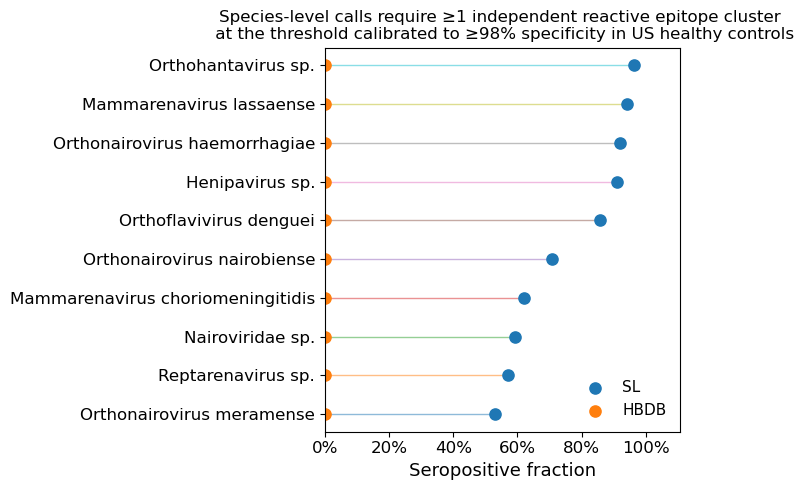

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Summarize seropositivity
species_plot = (
    breadth_species_df
    .groupby(['species', 'cohort'])['seropositive']
    .mean()
    .unstack()
    .fillna(0)
    .reset_index()
)

# Keep species with at least some CHILD seropositivity
species_plot = (
    species_plot
    .sort_values('SL', ascending=False)
)

# Optional: top 10 species
species_plot = species_plot.head(10).sort_values(
    'SL',
    ascending=True
)

fig, ax = plt.subplots(figsize=(7, 5))

y = np.arange(len(species_plot))

ax.scatter(
    species_plot['SL'],
    y,
    s=65,
    label='SL'
)

ax.scatter(
    species_plot['HBDB'],
    y,
    s=65,
    label='HBDB'
)

for i in range(len(species_plot)):
    ax.plot(
        [
            species_plot.iloc[i]['HBDB'],
            species_plot.iloc[i]['SL']
        ],
        [i, i],
        linewidth=1,
        alpha=0.5,
        zorder=0
    )

ax.set_yticks(y)
ax.set_yticklabels(
    species_plot['species'],
    fontsize=12
)

ax.set_xlabel(
    'Seropositive fraction',
    fontsize=13
)

ax.set_ylabel('')

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'{x:.0%}')
)

ax.tick_params(axis='x', labelsize=12)

ax.legend(
    frameon=False,
    fontsize=11
)

ax.set_xlim(0, max(species_plot['SL'].max(), 0.05) * 1.15)

plt.title('Species-level calls require ≥1 independent reactive epitope cluster \n at the threshold calibrated to ≥98% specificity in US healthy controls')
plt.tight_layout()
plt.show()

### next plot: distribution of independent epitope breadth

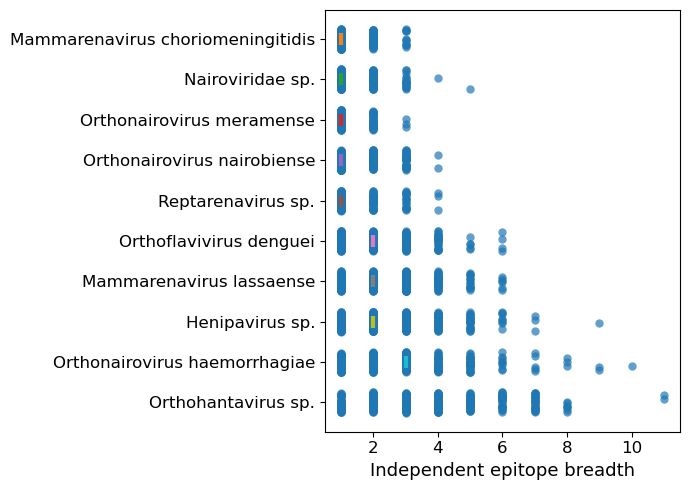

In [27]:
import seaborn as sns

plot_breadth = (
    breadth_species_df[
        (breadth_species_df['cohort'] == 'SL') &
        (breadth_species_df['seropositive'])
    ]
    .copy()
)

# Keep the same top species as the prevalence plot
top_species = species_plot['species'].tolist()

plot_breadth = plot_breadth[
    plot_breadth['species'].isin(top_species)
]

species_order = (
    plot_breadth
    .groupby('species')['breadth']
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(7, 5))

sns.stripplot(
    data=plot_breadth,
    x='breadth',
    y='species',
    order=species_order,
    jitter=0.25,
    size=6,
    alpha=0.7,
    ax=ax
)

# Median breadth
medians = (
    plot_breadth
    .groupby('species')['breadth']
    .median()
    .reindex(species_order)
)

for i, median in enumerate(medians):
    ax.scatter(
        median,
        i,
        s=80,
        marker='|',
        linewidths=3,
        zorder=5
    )

ax.set_xlabel(
    'Independent epitope breadth',
    fontsize=13
)

ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()
plt.show()

### calculate genus breadth 